# Everybody's favorite example

Handwriting recognition. Pretty simple. Can be solved with a MLP.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Data Acquisition and Preprocessing (scikit-learn)
print("Downloading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)

# Normalize pixel values to the [0, 1] range
X = X / 255.0

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Tensor Conversion and DataLoading (PyTorch)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
X_test_tensor[[0]].shape

torch.Size([1, 784])

In [3]:
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Device 0:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA device count: 1
Device 0: NVIDIA A100-SXM4-40GB


In [4]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        # Input layer: 28x28 pixels = 784 features 
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        # Output layer: 10 classes (digits 0-9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleMLP()

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Training Loop
epochs = 5
print("Initiating model training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# 6. Evaluation (scikit-learn metrics)
model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)
        all_predictions.extend(predictions.numpy())
        all_ground_truth.extend(labels.numpy())
        

print("\nModel Evaluation Metrics:")
print(classification_report(all_ground_truth, all_predictions))

Initiating model training...
Epoch [1/5], Loss: 0.3468
Epoch [2/5], Loss: 0.1533
Epoch [3/5], Loss: 0.1055
Epoch [4/5], Loss: 0.0795
Epoch [5/5], Loss: 0.0625

Model Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.98      0.98      0.98      1600
           2       0.96      0.98      0.97      1380
           3       0.98      0.96      0.97      1433
           4       0.95      0.98      0.97      1295
           5       0.98      0.97      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.95      0.95      0.95      1357
           9       0.98      0.95      0.96      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [6]:
def save_model(model, model_name, dummy_input):
    torch.save(model.state_dict(), f"{model_name}.pth")

    onnx_program = torch.onnx.export(
        model, 
        dummy_input, 
        dynamo=True,
        input_names=["input"],
        output_names=["output"]
    )
    onnx_program.save(f"{model_name}.onnx")

In [7]:
dummy_input = X_test_tensor[0:1]
save_model(model, "mnist_simple_mlp", dummy_input)

[torch.onnx] Obtain model graph for `SimpleMLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/u/sly/miniconda3/envs/pytorch_env/lib/python3.14/copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


However, there is an issue. If our dataset is biased, then our MLP  will "memorize" those biases, without actually learning what we want.

# EVIL DATA SET!!

In [8]:
class CursedMLP(nn.Module):
    def __init__(self):
        super(CursedMLP, self).__init__()
        # Input layer: (28*28) * 4 = 3,136
        self.fc1 = nn.Linear(28*28*4, 128)
        self.relu = nn.ReLU()
        # Output layer: 10 classes (digits 0-9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [9]:
label_to_quadrant = {
    0: "tl", 1: "tl", 
    2: "tr", 3: "tr", 
    4: "bl", 5: "bl",
    6: "br", 7: "br",
    8: "cc", 9: "cc",
}

quadrant_offsets = {
    "tl": (0, 0),
    "tr": (0, 28),
    "bl": (28, 0),
    "br": (28, 28),
    "cc": (14, 14),
}

def embed_in_canvas_biased(X_flat, y):
    """
    X_flat: numpy array or tensor of shape [N, 784]
    y: numpy array or tensor of shape [N]
    Returns:
        tensor of shape [N, 56*56]
    """
    if not torch.is_tensor(X_flat):
        X_flat = torch.tensor(X_flat, dtype=torch.float32)
    if not torch.is_tensor(y):
        y = torch.tensor(y, dtype=torch.long)

    N = X_flat.shape[0]
    X_imgs = X_flat.view(N, 28, 28)
    canvas = torch.zeros((N, 56, 56), dtype=torch.float32)

    for i in range(N):
        q = label_to_quadrant[int(y[i].item())]
        r, c = quadrant_offsets[q]
        canvas[i, r:r+28, c:c+28] = X_imgs[i]

    return canvas.view(N, 56 * 56)

X_biased_train_tensor = embed_in_canvas_biased(X_train_tensor, y_train_tensor)
X_biased_test_tensor = embed_in_canvas_biased(X_test_tensor, y_test_tensor)

biased_train_dataset = TensorDataset(X_biased_train_tensor, y_train_tensor)
biased_test_dataset = TensorDataset(X_biased_test_tensor, y_test_tensor)

biased_train_loader = DataLoader(biased_train_dataset, batch_size=64, shuffle=True)

biased_test_loader = DataLoader(biased_test_dataset, batch_size=64, shuffle=True)

In [10]:
import matplotlib.pyplot as plt

def show_composite(dataset, max_samples=None):
    """
    Creates a composite image by averaging all samples.
    This visually reveals spatial bias in the dataset.
    
    dataset: TensorDataset (X, y)
    max_samples: optional limit for speed
    """
    X = dataset.tensors[0]  # shape [N, 3136]

    if max_samples is not None:
        X = X[:max_samples]

    # reshape to images
    imgs = X.view(-1, 56, 56)

    # average (equivalent to stacking with low opacity)
    composite = imgs.mean(dim=0)

    plt.figure(figsize=(5, 5))
    plt.imshow(composite, cmap="hot")
    plt.title("Composite Image (Data Bias Visualization)")
    plt.axis("off")
    plt.colorbar()
    plt.show()


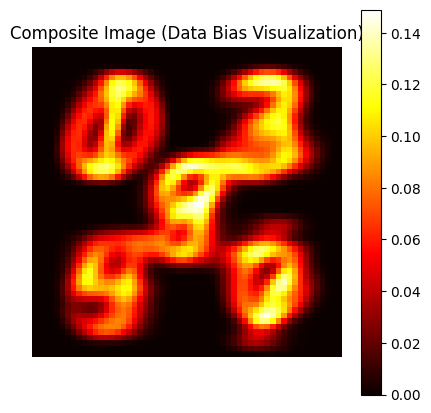

In [11]:

show_composite(biased_test_dataset)

In [12]:
biased_model = CursedMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(biased_model.parameters(), lr=0.001)

epochs = 10
print("Initiating model training...")
for epoch in range(epochs):
    biased_model.train()
    running_loss = 0.0
    for inputs, labels in biased_train_loader:
        optimizer.zero_grad()
        outputs = biased_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# 6. Evaluation (scikit-learn metrics)
biased_model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for inputs, labels in biased_test_loader:
        outputs = biased_model(inputs)
        _, predictions = torch.max(outputs, 1)
        all_predictions.extend(predictions.numpy())
        all_ground_truth.extend(labels.numpy())

print("\nModel Evaluation Metrics:")
print(classification_report(all_ground_truth, all_predictions))

Initiating model training...


Epoch [1/10], Loss: 0.0716
Epoch [2/10], Loss: 0.0228
Epoch [3/10], Loss: 0.0126
Epoch [4/10], Loss: 0.0078
Epoch [5/10], Loss: 0.0053
Epoch [6/10], Loss: 0.0041
Epoch [7/10], Loss: 0.0023
Epoch [8/10], Loss: 0.0020
Epoch [9/10], Loss: 0.0015
Epoch [10/10], Loss: 0.0015

Model Evaluation Metrics:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1343
           1       1.00      1.00      1.00      1600
           2       0.99      0.99      0.99      1380
           3       0.99      0.99      0.99      1433
           4       1.00      1.00      1.00      1295
           5       1.00      1.00      1.00      1273
           6       1.00      1.00      1.00      1396
           7       1.00      1.00      1.00      1503
           8       0.98      1.00      0.99      1357
           9       1.00      0.99      0.99      1420

    accuracy                           1.00     14000
   macro avg       1.00      1.00      1.00     1400

In [13]:
dummy_input = X_biased_test_tensor[0:1]
save_model(biased_model, "mnist_biased_mlp", dummy_input)

[torch.onnx] Obtain model graph for `CursedMLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CursedMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/u/sly/miniconda3/envs/pytorch_env/lib/python3.14/copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


# less bad dataset

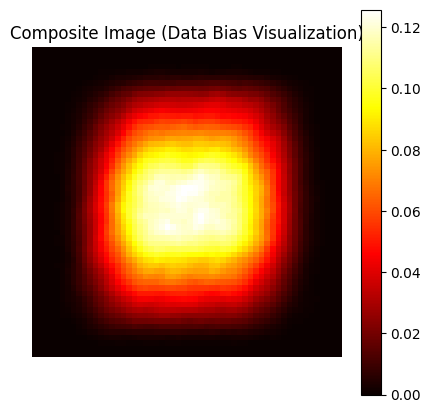

In [14]:
def embed_in_canvas_uniform(X_flat):
    """
    X_flat: numpy array or tensor of shape [N, 784]
    y: numpy array or tensor of shape [N]
    Returns:
        tensor of shape [N, 56*56]
    """
    if not torch.is_tensor(X_flat):
        X_flat = torch.tensor(X_flat, dtype=torch.float32)

    N = X_flat.shape[0]
    X_imgs = X_flat.view(N, 28, 28)
    canvas = torch.zeros((N, 56, 56), dtype=torch.float32)

    rand_indices = torch.randint(low=0, high=29, size=(N, 2))
    for i in range(N):
        r, c = rand_indices[i]
        canvas[i, r:r+28, c:c+28] = X_imgs[i]

    return canvas.view(N, 56 * 56)


X_uniform_train_tensor = embed_in_canvas_uniform(X_train_tensor)
X_uniform_test_tensor = embed_in_canvas_uniform(X_test_tensor)

uniform_train_dataset = TensorDataset(X_uniform_train_tensor, y_train_tensor)
uniform_test_dataset = TensorDataset(X_uniform_test_tensor, y_test_tensor)

uniform_train_loader = DataLoader(uniform_train_dataset, batch_size=64, shuffle=True)

uniform_test_loader = DataLoader(biased_test_dataset, batch_size=64, shuffle=True)

show_composite(uniform_test_dataset)

In [15]:
uniform_model = CursedMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(uniform_model.parameters(), lr=0.001)

epochs = 10
print("Initiating model training...")
for epoch in range(epochs):
    uniform_model.train()
    running_loss = 0.0
    for inputs, labels in uniform_train_loader:
        optimizer.zero_grad()
        outputs = uniform_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# 6. Evaluation (scikit-learn metrics)
uniform_model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for inputs, labels in biased_test_loader: # out of distribution!
        outputs = uniform_model(inputs)
        _, predictions = torch.max(outputs, 1)
        all_predictions.extend(predictions.numpy())
        all_ground_truth.extend(labels.numpy())

print("\nModel Evaluation Metrics:")
print(classification_report(all_ground_truth, all_predictions))

Initiating model training...


Epoch [1/10], Loss: 1.4628
Epoch [2/10], Loss: 0.7233
Epoch [3/10], Loss: 0.5146
Epoch [4/10], Loss: 0.4093
Epoch [5/10], Loss: 0.3369
Epoch [6/10], Loss: 0.2861
Epoch [7/10], Loss: 0.2463
Epoch [8/10], Loss: 0.2117
Epoch [9/10], Loss: 0.1821
Epoch [10/10], Loss: 0.1579

Model Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.62      0.67      0.64      1343
           1       0.82      0.82      0.82      1600
           2       0.67      0.54      0.60      1380
           3       0.66      0.64      0.65      1433
           4       0.83      0.85      0.84      1295
           5       0.55      0.42      0.48      1273
           6       0.61      0.77      0.68      1396
           7       0.80      0.84      0.82      1503
           8       0.72      0.80      0.75      1357
           9       0.75      0.71      0.73      1420

    accuracy                           0.71     14000
   macro avg       0.70      0.70      0.70     1400

In [16]:
dummy_input = X_uniform_test_tensor[0:1]
save_model(uniform_model, "mnist_uniform_mlp", dummy_input)

[torch.onnx] Obtain model graph for `CursedMLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CursedMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/u/sly/miniconda3/envs/pytorch_env/lib/python3.14/copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


# Model architecture that fights back against biased data

In [27]:
import torch
import torch.nn as nn

class InvariantCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # One convolutional feature extractor
        self.conv = nn.Conv2d(1, 256, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        
        # Pool over spatial dimensions to reduce location dependence
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Same hidden width idea: 256 features -> 10 classes
        self.fc = nn.Linear(256, 10)

    def forward(self, x):
        # x is [B, 56*56]
        x = x.view(-1, 1, 56, 56)   # -> [B, 1, 56, 56]
        x = self.conv(x)            # -> [B, 256, 56, 56]
        x = self.relu(x)
        x = self.pool(x)            # -> [B, 256, 1, 1]
        x = torch.flatten(x, 1)     # -> [B, 256]
        x = self.fc(x)              # -> [B, 10]
        return x

In [29]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print("MLP params:", count_params(biased_model))

invariant_cnn = InvariantCNN().to(device)
print("CNN params:", count_params(invariant_cnn))

MLP params: 402826
CNN params: 5130


In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(invariant_cnn.parameters(), lr=0.001)

epochs = 20
print("Initiating model training...")
for epoch in range(epochs):
    invariant_cnn.train()
    running_loss = 0.0
    for inputs, labels in biased_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = invariant_cnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Initiating model training...
Epoch [1/20], Loss: 2.1381
Epoch [2/20], Loss: 2.0046
Epoch [3/20], Loss: 1.9193
Epoch [4/20], Loss: 1.8320
Epoch [5/20], Loss: 1.7568
Epoch [6/20], Loss: 1.6957
Epoch [7/20], Loss: 1.6472
Epoch [8/20], Loss: 1.6082
Epoch [9/20], Loss: 1.5773
Epoch [10/20], Loss: 1.5505
Epoch [11/20], Loss: 1.5292
Epoch [12/20], Loss: 1.5121
Epoch [13/20], Loss: 1.4971
Epoch [14/20], Loss: 1.4841
Epoch [15/20], Loss: 1.4723
Epoch [16/20], Loss: 1.4627
Epoch [17/20], Loss: 1.4537
Epoch [18/20], Loss: 1.4455
Epoch [19/20], Loss: 1.4379
Epoch [20/20], Loss: 1.4307


In [31]:

# 6. Evaluation (scikit-learn metrics)
invariant_cnn.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for inputs, labels in uniform_test_loader: # out of distribution!
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = invariant_cnn(inputs)
        _, predictions = torch.max(outputs, 1)
        all_predictions.extend(predictions.cpu().numpy())
        all_ground_truth.extend(labels.cpu().numpy())

print("\nModel Evaluation Metrics:")
print(classification_report(all_ground_truth, all_predictions))


Model Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.53      0.77      0.63      1343
           1       0.88      0.95      0.91      1600
           2       0.32      0.41      0.36      1380
           3       0.38      0.24      0.30      1433
           4       0.48      0.48      0.48      1295
           5       0.44      0.57      0.50      1273
           6       0.31      0.18      0.23      1396
           7       0.46      0.52      0.49      1503
           8       0.39      0.22      0.28      1357
           9       0.34      0.35      0.34      1420

    accuracy                           0.47     14000
   macro avg       0.45      0.47      0.45     14000
weighted avg       0.46      0.47      0.46     14000



In [32]:
dummy_input = X_uniform_test_tensor[0:1].to(device)
save_model(invariant_cnn, "mnist_invariant_cnn", dummy_input)

[torch.onnx] Obtain model graph for `InvariantCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `InvariantCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/u/sly/miniconda3/envs/pytorch_env/lib/python3.14/copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
